# Multitask ConvNeXt + StarDist Training — GS40 Dataset

**Goal:** One forward pass → nuclear instance segmentation + per-nucleus cell-type classification.

## Workflow
| Step | What it does |
|------|--------------|
| 1 | **Paths & imports** — define all directories, class names, output locations |
| 2 | **Load split stems** — fold-0 CSVs; create 80/20 if not yet generated |
| 3 | **Rasterize masks** — StarDist JSON → uint16 instance mask `.png` for any stem missing a mask |
| 4 | **Build `inst2class` sidecars** — KD-tree matching: CellViT CSV centroids → nearest StarDist instance → `{stem}_inst2class.json` |
| 4b | **Diagnostic** — measure inst2class match rate, centroid distances, flag low-match tiles |
| 5 | **Audit & failsafe** — catch corrupt TIFFs, empty JSONs, class-name mismatches; hard `assert` (MIN_JSON_COV=80%) |
| 6 | **Filter valid stems** — keep only stems with mask + inst2class; save `train_full.csv`/`val_full.csv` |
| 7 | **Visualise samples** — image / mask / class-map for random train & val tiles |
| 8 | **Write config YAML** — generate `config_gs40_multitask.yaml` with explicit stem lists |
| 9 | **Run training** — CLI command (or run in-notebook via `!`) |

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from pathlib import Path
import json, shutil, random
import numpy as np
import pandas as pd
import cv2
import tifffile
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Canonical paths ───────────────────────────────────────────────────────────
# DATASET_ROOT      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\data_for_cellvit_GS40_balanced")
DATASET_ROOT      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides")
TRAIN_IMAGES_DIR  = DATASET_ROOT / "train" / "images"
TRAIN_CSV_DIR     = DATASET_ROOT / "train" / "labels"
VAL_CSV_DIR       = DATASET_ROOT / "val"   / "labels"
STARDIST_JSON_DIR = TRAIN_IMAGES_DIR / "StarDist_4_3_2026_cross_fetal_species" / "json"
MT_READY_DIR      = DATASET_ROOT / "stardist_multitask_ready"
INST_LABELS_DIR   = MT_READY_DIR / "train_instance_labels"   # single dir used for both train & val
SPLITS_DIR        = MT_READY_DIR / "splits"
CONFIG_PATH       = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml")
CKPT_OUT          = DATASET_ROOT / "convnext_stardist_multitask_runs" / "run_fold0_FULL"

# ── Class names (must match model.class_names in YAML) ───────────────────────
CLASS_NAMES = [
    "bladder", "bone", "brain", "collagen", "ear", "eye", "gi", "heart",
    "kidney", "liver", "lungs", "mesokidney", "nontissue", "pancreas",
    "skull", "spleen", "spleen2", "thymus", "thyroid",
]
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}

for d in [INST_LABELS_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Quick existence check ─────────────────────────────────────────────────────
checks = [
    ("DATASET_ROOT",    DATASET_ROOT),
    ("TRAIN_IMAGES",    TRAIN_IMAGES_DIR),
    ("TRAIN_CSV_LABELS",TRAIN_CSV_DIR),
    ("STARDIST_JSON",   STARDIST_JSON_DIR),
]
all_ok = True
for label, p in checks:
    ok = p.exists()
    all_ok = all_ok and ok
    print(f"  {'OK' if ok else 'MISSING'}  {label}: {p}")
if not all_ok:
    raise RuntimeError("One or more required directories are missing. Fix paths above before continuing.")
print("\nAll required paths found.")

  OK  DATASET_ROOT: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides
  OK  TRAIN_IMAGES: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train\images
  OK  TRAIN_CSV_LABELS: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train\labels
  OK  STARDIST_JSON: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\train\images\StarDist_4_3_2026_cross_fetal_species\json

All required paths found.


## Step 1 — Load split stems
Load from `stardist_multitask_ready/splits/train_full.csv` (generated by this notebook on first run).  
Falls back to fold-0 CSVs when `train_full.csv` does not yet exist.

In [2]:
FOLD0_TRAIN_CSV = DATASET_ROOT / "splits" / "fold_0" / "train.csv"
FOLD0_VAL_CSV   = DATASET_ROOT / "splits" / "fold_0" / "val.csv"
TRAIN_FULL_CSV  = SPLITS_DIR / "train_full.csv"
VAL_FULL_CSV    = SPLITS_DIR / "val_full.csv"

# Header names that old runs may have written as the first data row
_HEADER_NAMES = {"stem", "stems", "image", "images", "file", "filename",
                 "name", "tile", "tiles", "0", "1", "index", "path"}

def read_stems(csv_path: Path) -> list:
    df = pd.read_csv(csv_path, header=None)
    raw = df.iloc[:, 0].dropna().astype(str).tolist()
    stems = [Path(s).stem for s in raw]
    # Drop likely CSV header rows (very short or known column-name strings)
    stems = [s for s in stems if s and s.lower() not in _HEADER_NAMES and len(s) > 5]
    # Deduplicate while preserving order
    seen = set()
    return [s for s in stems if not (s in seen or seen.add(s))]

if TRAIN_FULL_CSV.exists() and VAL_FULL_CSV.exists():
    train_stems = read_stems(TRAIN_FULL_CSV)
    val_stems   = read_stems(VAL_FULL_CSV)
    print(f"Loaded from train_full/val_full.csv  — train: {len(train_stems)}  val: {len(val_stems)}")
elif FOLD0_TRAIN_CSV.exists() and FOLD0_VAL_CSV.exists():
    train_stems = read_stems(FOLD0_TRAIN_CSV)
    val_stems   = read_stems(FOLD0_VAL_CSV)
    print(f"Loaded from fold_0 CSVs  — train: {len(train_stems)}  val: {len(val_stems)}")
else:
    # Build an 80/20 split from all available images
    all_imgs = sorted(TRAIN_IMAGES_DIR.glob("*.png")) + \
               sorted(TRAIN_IMAGES_DIR.glob("*.jpg")) + \
               sorted(TRAIN_IMAGES_DIR.glob("*.tif"))
    all_stems = [p.stem for p in all_imgs]
    random.seed(42)
    random.shuffle(all_stems)
    cut = int(0.8 * len(all_stems))
    train_stems, val_stems = all_stems[:cut], all_stems[cut:]
    # Write plain text, one stem per line — no index, no header
    TRAIN_FULL_CSV.write_text("\n".join(train_stems) + "\n", encoding="utf-8")
    VAL_FULL_CSV.write_text("\n".join(val_stems) + "\n", encoding="utf-8")
    print(f"Created 80/20 split  — train: {len(train_stems)}  val: {len(val_stems)}")
    print(f"  Saved: {TRAIN_FULL_CSV}")
    print(f"  Saved: {VAL_FULL_CSV}")

# ── Failsafe: no data leakage ─────────────────────────────────────────────────
overlap = set(train_stems) & set(val_stems)
assert len(overlap) == 0, f"DATA LEAK: {len(overlap)} stems appear in BOTH train and val: {list(overlap)[:5]}"
assert len(train_stems) >= 100, f"Too few training stems: {len(train_stems)}"
assert len(val_stems)   >= 20,  f"Too few validation stems: {len(val_stems)}"
print(f"\nFailsafe checks passed:")
print(f"  No train/val overlap ✓")
print(f"  Min train count (100): {len(train_stems)} ✓")
print(f"  Min val count (20):    {len(val_stems)} ✓")

Loaded from train_full/val_full.csv  — train: 38637  val: 8006

Failsafe checks passed:
  No train/val overlap ✓
  Min train count (100): 38637 ✓
  Min val count (20):    8006 ✓


## Step 2 — Rasterize missing instance masks
For each stem that is missing a mask in `INST_LABELS_DIR`, rasterize the corresponding  
StarDist JSON polygon file → uint16 PNG (0 = background, each nucleus a unique integer id).  
Already-existing masks are **not** overwritten.

In [4]:
all_stems = list(dict.fromkeys(train_stems + val_stems))   # ordered, unique

missing_mask = [s for s in all_stems if not (INST_LABELS_DIR / f"{s}.png").exists()
                                       and not (INST_LABELS_DIR / f"{s}.tif").exists()]
print(f"Total stems:       {len(all_stems)}")
print(f"Existing masks:    {len(all_stems) - len(missing_mask)}")
print(f"Stems needing rasterization: {len(missing_mask)}")

skipped, failed, created = 0, 0, 0
for stem in tqdm(missing_mask, desc="Rasterize masks"):
    json_path = STARDIST_JSON_DIR / f"{stem}.json"
    if not json_path.exists():
        skipped += 1
        continue

    # Find image to get spatial dimensions
    img_path = None
    for ext in (".png", ".jpg", ".tif"):
        cand = TRAIN_IMAGES_DIR / f"{stem}{ext}"
        if cand.exists():
            img_path = cand
            break
    if img_path is None:
        skipped += 1
        continue

    try:
        with Image.open(img_path) as im:
            w, h = im.size
        mask = np.zeros((h, w), dtype=np.uint16)

        with json_path.open("r", encoding="utf-8") as f:
            polys = json.load(f)

        for inst_id, obj in enumerate(polys, start=1):
            contour = obj.get("contour", [])
            if not contour:
                continue
            y_coords = contour[0][0]
            x_coords = contour[0][1]
            pts = np.column_stack((x_coords, y_coords)).astype(np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(mask, [pts], color=inst_id)

        out_path = INST_LABELS_DIR / f"{stem}.png"
        cv2.imwrite(str(out_path), mask)
        created += 1
    except Exception as e:
        print(f"  Failed {stem}: {e}")
        failed += 1

print(f"\nRasterization complete:")
print(f"  Created: {created}")
print(f"  Skipped (no JSON/image): {skipped}")
print(f"  Failed:  {failed}")
print(f"  Total masks now in dir: {len(list(INST_LABELS_DIR.glob('*.png')) + list(INST_LABELS_DIR.glob('*.tif')))}")

Total stems:       46643
Existing masks:    46643
Stems needing rasterization: 0


Rasterize masks: 0it [00:00, ?it/s]


Rasterization complete:
  Created: 0
  Skipped (no JSON/image): 0
  Failed:  0
  Total masks now in dir: 46643


## Step 3 — Build `inst2class` JSON sidecars

**V2 approach** — KD-tree nearest-neighbor matching (replaces the V1 pixel-lookup).

For each stem, compute **StarDist instance centroids** from the mask, build a KD-tree, then match each CellViT CSV centroid to the **nearest** StarDist instance (within `MAX_MATCH_DIST_PX`).

This avoids two failure modes of the old pixel-lookup:
1. CellViT centroid falling on mask background (boundary pixel)
2. CellViT centroid landing inside a neighbouring StarDist polygon

Writes `{stem}_inst2class.json` → `{"1": "5", "3": "7", ...}` (inst_id → class index as string).  
Set `FORCE_REBUILD_INST2CLASS = True` to overwrite existing sidecars.

In [5]:
from scipy.spatial import cKDTree

FORCE_REBUILD_INST2CLASS = True   # True → overwrite existing JSONs with the improved matcher
MAX_MATCH_DIST_PX = 15            # max distance (px) between CellViT centroid and StarDist centroid

def find_mask(stem: str) -> Path | None:
    for ext in (".png", ".tif", ".tiff"):
        p = INST_LABELS_DIR / f"{stem}{ext}"
        if p.exists():
            return p
    return None

def load_mask_safe(path: Path) -> np.ndarray | None:
    """Load instance mask; return None on any error (corrupt, empty, etc)."""
    try:
        if path.suffix.lower() in (".tif", ".tiff"):
            with tifffile.TiffFile(path) as tf:
                if len(tf.pages) == 0:
                    return None
            arr = tifffile.imread(path)
        else:
            arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if arr is None or arr.size == 0:
            return None
        if arr.ndim != 2:
            arr = arr.squeeze()
        return arr.astype(np.int32)
    except Exception:
        return None


def _stardist_centroids(mask: np.ndarray) -> dict[int, tuple[float, float]]:
    """Compute centroid (x, y) for each instance in an int mask. O(H*W)."""
    flat = mask.ravel()
    h, w = mask.shape
    ys, xs = np.divmod(np.arange(h * w), w)
    centroids: dict[int, tuple[float, float]] = {}
    for inst_id in np.unique(flat):
        if inst_id == 0:
            continue
        m = flat == inst_id
        centroids[int(inst_id)] = (float(xs[m].mean()), float(ys[m].mean()))
    return centroids


def build_inst2class(stem: str, csv_dir: Path) -> dict | None:
    """
    KD-tree nearest-neighbor matching: CellViT CSV centroids → StarDist instances.
    Returns {inst_id_str: cls_idx_str} or None.
    """
    csv_path = csv_dir / f"{stem}.csv"
    mask_path = find_mask(stem)
    if not csv_path.exists() or mask_path is None:
        return None
    try:
        df = pd.read_csv(csv_path, header=None)
    except Exception:
        return None
    if len(df.columns) < 3:
        return None
    df = df.iloc[:, :3]
    df.columns = ["x", "y", "class"]

    mask = load_mask_safe(mask_path)
    if mask is None:
        return None

    sd_centroids = _stardist_centroids(mask)
    if not sd_centroids:
        return None

    inst_ids = list(sd_centroids.keys())
    coords = np.array([sd_centroids[i] for i in inst_ids], dtype=np.float64)
    tree = cKDTree(coords)

    out: dict[str, str] = {}
    for _, row in df.iterrows():
        try:
            cx, cy = float(row["x"]), float(row["y"])
            class_raw = str(row["class"]).strip().lower()
        except (ValueError, TypeError):
            continue
        try:
            cls_idx = int(float(class_raw))
            if not (0 <= cls_idx < len(CLASS_NAMES)):
                continue
        except ValueError:
            cls_idx = CLASS_TO_IDX.get(class_raw)
            if cls_idx is None:
                continue

        dist, idx = tree.query([cx, cy])
        if dist > MAX_MATCH_DIST_PX:
            continue
        matched_id = str(inst_ids[idx])
        if matched_id not in out:
            out[matched_id] = str(cls_idx)
    return out if out else None


# ── Run for all stems ─────────────────────────────────────────────────────────
created_j = skipped_j = failed_j = 0
for stem in tqdm(all_stems, desc="Build inst2class JSONs"):
    out_path = INST_LABELS_DIR / f"{stem}_inst2class.json"
    if out_path.exists() and not FORCE_REBUILD_INST2CLASS:
        skipped_j += 1
        continue
    mapping = build_inst2class(stem, TRAIN_CSV_DIR)
    if mapping is None:
        mapping = build_inst2class(stem, VAL_CSV_DIR)
    if mapping is None:
        failed_j += 1
        continue
    out_path.write_text(json.dumps(mapping), encoding="utf-8")
    created_j += 1

print(f"\ninst2class sidecars (KD-tree, max_dist={MAX_MATCH_DIST_PX} px):")
print(f"  Created:  {created_j}")
print(f"  Skipped (already exist): {skipped_j}")
print(f"  Failed (no CSV/mask/matches): {failed_j}")

Build inst2class JSONs:   0%|          | 0/46643 [00:00<?, ?it/s]


inst2class sidecars (KD-tree, max_dist=15 px):
  Created:  46639
  Skipped (already exist): 0
  Failed (no CSV/mask/matches): 4


## Step 3b — Diagnostic: inst2class match quality

Measures how many StarDist nuclei received a class label and how close the CellViT centroids were to the matched StarDist centroids. This validates the KD-tree matching quality.

In [6]:
# ── Diagnostic: inst2class match quality ─────────────────────────────────────
N_DIAG = min(500, len(all_stems))
diag_stems = random.sample(all_stems, N_DIAG)

total_sd_nuclei = 0
total_matched = 0
match_dists = []
tiles_zero_matches = 0
tiles_low_match = []

for stem in tqdm(diag_stems, desc="Diagnosing match quality"):
    mask_path = find_mask(stem)
    if mask_path is None:
        continue
    mask = load_mask_safe(mask_path)
    if mask is None:
        continue

    n_sd = len(np.unique(mask)) - 1  # exclude background
    if n_sd == 0:
        continue

    j_path = INST_LABELS_DIR / f"{stem}_inst2class.json"
    if not j_path.exists():
        tiles_zero_matches += 1
        total_sd_nuclei += n_sd
        continue
    try:
        inst2cls = json.loads(j_path.read_bytes().decode("utf-8-sig"))
    except Exception:
        tiles_zero_matches += 1
        total_sd_nuclei += n_sd
        continue

    n_matched = len(inst2cls)
    total_sd_nuclei += n_sd
    total_matched += n_matched
    if n_matched == 0:
        tiles_zero_matches += 1
        continue

    # Measure centroid-to-centroid distances for matched instances
    csv_path = TRAIN_CSV_DIR / f"{stem}.csv"
    if not csv_path.exists():
        csv_path = VAL_CSV_DIR / f"{stem}.csv"
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path, header=None).iloc[:, :3]
            df.columns = ["x", "y", "class"]
            sd_c = _stardist_centroids(mask)
            for inst_str in inst2cls:
                iid = int(inst_str)
                if iid in sd_c:
                    sx, sy = sd_c[iid]
                    for _, r in df.iterrows():
                        cx, cy = float(r["x"]), float(r["y"])
                        d = np.sqrt((cx - sx)**2 + (cy - sy)**2)
                        if d <= MAX_MATCH_DIST_PX:
                            match_dists.append(d)
                            break
        except Exception:
            pass

    match_rate = n_matched / n_sd
    if match_rate < 0.3:
        tiles_low_match.append((stem, n_matched, n_sd, match_rate))

overall_rate = total_matched / max(total_sd_nuclei, 1)
print(f"\n{'='*60}")
print(f"  inst2class MATCH QUALITY  (sampled {N_DIAG} tiles)")
print(f"{'='*60}")
print(f"  Total StarDist nuclei : {total_sd_nuclei:,}")
print(f"  Matched (have class)  : {total_matched:,}")
print(f"  Overall match rate    : {100*overall_rate:.1f}%")
print(f"  Tiles with 0 matches : {tiles_zero_matches}")
if match_dists:
    md = np.array(match_dists)
    print(f"  Match distance (px)   : mean={md.mean():.1f}  median={np.median(md):.1f}  "
          f"p95={np.percentile(md, 95):.1f}  max={md.max():.1f}")
if tiles_low_match:
    print(f"  Tiles with <30% match : {len(tiles_low_match)}")
    for s, nm, ns, mr in tiles_low_match[:5]:
        print(f"    {s}: {nm}/{ns} = {100*mr:.0f}%")

if overall_rate < 0.5:
    print("\n  WARNING: match rate below 50% — consider lowering MAX_MATCH_DIST_PX "
          "or checking that CSV and mask stems align.")
elif overall_rate < 0.7:
    print("\n  NOTE: match rate 50-70% — many StarDist nuclei have no class label. "
          "Classification head trains on partial supervision (ignore_index=-100).")
else:
    print(f"\n  Match rate looks healthy ({100*overall_rate:.0f}%).")

Diagnosing match quality:   0%|          | 0/500 [00:00<?, ?it/s]


  inst2class MATCH QUALITY  (sampled 500 tiles)
  Total StarDist nuclei : 36,248
  Matched (have class)  : 31,082
  Overall match rate    : 85.7%
  Tiles with 0 matches : 0
  Tiles with <30% match : 2
    monkey_fetus_40_0526_x20160_y10976_dup2: 5/30 = 17%
    monkey_fetus_40_0656_x26880_y20832: 6/21 = 29%

  Match rate looks healthy (86%).


## Step 4 — Audit & failsafe checks
Scans every mask and sidecar JSON for the split stems and reports:
- Corrupt / empty TIFFs
- Empty or invalid JSON sidecars
- Class names in JSON that do not match `CLASS_NAMES`

**Hard asserts** stop the notebook if coverage is below acceptable thresholds.

In [7]:
def audit_stems(stems: list, label: str) -> dict:
    """Audit a list of stems; return coverage stats."""
    known_names = set(CLASS_NAMES) | {str(i) for i in range(len(CLASS_NAMES))}
    n = len(stems)
    has_mask      = 0
    has_json      = 0
    bad_masks     = []
    bad_jsons     = []
    empty_jsons   = []
    foreign_names = {}

    for stem in tqdm(stems, desc=f"Audit {label}", leave=False):
        mask_path = find_mask(stem)
        if mask_path is None:
            bad_masks.append(stem)
        else:
            arr = load_mask_safe(mask_path)
            if arr is None:
                bad_masks.append(stem)
            else:
                has_mask += 1

        j_path = INST_LABELS_DIR / f"{stem}_inst2class.json"
        if not j_path.exists():
            continue
        try:
            raw_bytes = j_path.read_bytes().strip()
            if not raw_bytes:
                empty_jsons.append(stem)
                continue
            data = json.loads(raw_bytes.decode("utf-8-sig"))
        except Exception:
            bad_jsons.append(stem)
            continue
        if not isinstance(data, dict) or len(data) == 0:
            empty_jsons.append(stem)
            continue
        unknown = {str(v).strip().lower() for v in data.values()} - known_names
        if unknown:
            foreign_names[stem] = unknown
        has_json += 1

    mask_cov = 100.0 * has_mask / max(n, 1)
    json_cov = 100.0 * has_json / max(n, 1)

    print(f"\n{'='*60}")
    print(f"  {label.upper()} ({n} stems)")
    print(f"{'='*60}")
    print(f"  Mask coverage:          {has_mask}/{n} ({mask_cov:.1f}%)")
    print(f"  inst2class coverage:    {has_json}/{n} ({json_cov:.1f}%)")
    print(f"  Bad/missing masks:      {len(bad_masks)}")
    print(f"  Bad JSONs (corrupt):    {len(bad_jsons)}")
    print(f"  Empty JSONs (0 matches):{len(empty_jsons)}")
    print(f"  JSONs with unknown class names: {len(foreign_names)}")
    if bad_masks:
        print(f"  Bad mask stems (first 5): {bad_masks[:5]}")
    if bad_jsons:
        print(f"  Bad JSON stems (first 5): {bad_jsons[:5]}")
    if foreign_names:
        all_foreign = set().union(*foreign_names.values())
        print(f"  Unknown class names found: {sorted(all_foreign)}")
        print(f"  ACTION: Add to CLASS_NAMES or fix the JSON values.")

    return {
        "n": n, "has_mask": has_mask, "has_json": has_json,
        "mask_cov": mask_cov, "json_cov": json_cov,
        "bad_masks": bad_masks, "bad_jsons": bad_jsons,
        "empty_jsons": empty_jsons, "foreign_names": foreign_names,
    }

train_audit = audit_stems(train_stems, "TRAIN")
val_audit   = audit_stems(val_stems,   "VAL")

# ── Hard failsafes ────────────────────────────────────────────────────────────
MIN_MASK_COV = 80.0
MIN_JSON_COV = 80.0   # raised from 50% — KD-tree matching should hit this easily
for audit, split in [(train_audit, "TRAIN"), (val_audit, "VAL")]:
    assert audit["mask_cov"] >= MIN_MASK_COV, \
        f"{split} mask coverage {audit['mask_cov']:.1f}% < {MIN_MASK_COV}%. Re-run Step 2."
    assert audit["json_cov"] >= MIN_JSON_COV, \
        f"{split} inst2class coverage {audit['json_cov']:.1f}% < {MIN_JSON_COV}%. Re-run Step 3."
    assert len(audit["foreign_names"]) == 0, \
        f"{split} has {len(audit['foreign_names'])} stems with unknown class identifiers.\n"\
        f"  Unknown values: {sorted(set().union(*audit['foreign_names'].values()) if audit['foreign_names'] else [])}\n"\
        f"  Valid values are CLASS_NAMES strings OR integer indices 0-{len(CLASS_NAMES)-1}."

print("\nAll failsafe checks passed.")

Audit TRAIN:   0%|          | 0/38637 [00:00<?, ?it/s]


  TRAIN (38637 stems)
  Mask coverage:          38637/38637 (100.0%)
  inst2class coverage:    38634/38637 (100.0%)
  Bad/missing masks:      0
  Bad JSONs (corrupt):    0
  Empty JSONs (0 matches):0
  JSONs with unknown class names: 0


Audit VAL:   0%|          | 0/8006 [00:00<?, ?it/s]


  VAL (8006 stems)
  Mask coverage:          8006/8006 (100.0%)
  inst2class coverage:    8005/8006 (100.0%)
  Bad/missing masks:      0
  Bad JSONs (corrupt):    0
  Empty JSONs (0 matches):0
  JSONs with unknown class names: 0

All failsafe checks passed.


## Step 5 — Filter valid stems & save final split CSVs
Keep only stems that have **both** a valid mask **and** an `inst2class` JSON.  
Stems without a JSON will still train `prob`/`dist` — include or exclude based on your needs.

In [8]:
REQUIRE_JSON = False   # Set True to exclude stems with no inst2class (stricter but fewer samples)

bad_train = set(train_audit["bad_masks"] + train_audit["bad_jsons"])
bad_val   = set(val_audit["bad_masks"]   + val_audit["bad_jsons"])

def has_json(stem: str) -> bool:
    j = INST_LABELS_DIR / f"{stem}_inst2class.json"
    if not j.exists():
        return False
    try:
        d = json.loads(j.read_bytes().decode("utf-8-sig"))
        return isinstance(d, dict) and len(d) > 0
    except Exception:
        return False

def filter_stems(stems: list, bad: set, require_json: bool) -> list:
    filtered = []
    for s in stems:
        if s in bad:
            continue
        if find_mask(s) is None:
            continue
        if require_json and not has_json(s):
            continue
        filtered.append(s)
    return filtered

final_train = filter_stems(train_stems, bad_train, REQUIRE_JSON)
final_val   = filter_stems(val_stems,   bad_val,   REQUIRE_JSON)

# Persist the filtered lists — plain text, no header, no index
TRAIN_FULL_CSV.write_text("\n".join(final_train) + "\n", encoding="utf-8")
VAL_FULL_CSV.write_text("\n".join(final_val) + "\n", encoding="utf-8")

print(f"Final training stems:   {len(final_train)} (removed {len(train_stems)-len(final_train)})")
print(f"Final validation stems: {len(final_val)}   (removed {len(val_stems)-len(final_val)})")
print(f"Saved: {TRAIN_FULL_CSV}")
print(f"Saved: {VAL_FULL_CSV}")

# Re-assign for downstream cells
train_stems = final_train
val_stems   = final_val

# Final overlap check after filtering
assert len(set(train_stems) & set(val_stems)) == 0, "DATA LEAK after filtering!"
print("\nNo train/val overlap after filtering ✓")

Final training stems:   38637 (removed 0)
Final validation stems: 8006   (removed 0)
Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\stardist_multitask_ready\splits\train_full.csv
Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\stardist_multitask_ready\splits\val_full.csv

No train/val overlap after filtering ✓


## Step 6 — Visualise random samples
For each random tile: image · instance mask (coloured) · class map (per-nucleus label).  
Use this to confirm images, masks, and classification targets look reasonable before training.

In [9]:
TRAIN_IMAGES_DIR

WindowsPath('//kittyserverdw/Andre_kit/data/students/Diogo/data/fetal/GS40/cellvit_training/dataset_224_40k_48_slides/train/images')

C:\Users\Andre\AppData\Local\Temp\ipykernel_51264\590750551.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap("tab20", len(CLASS_NAMES))


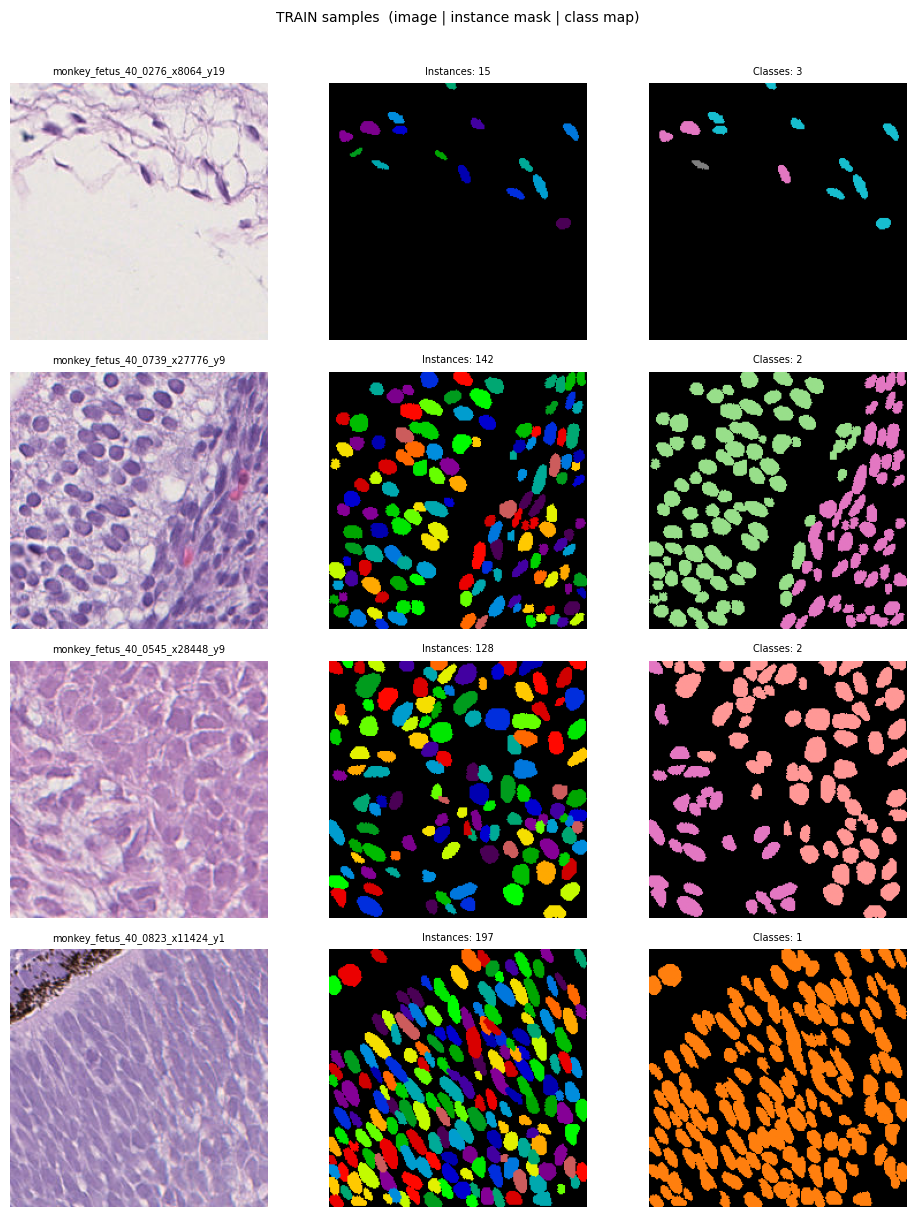

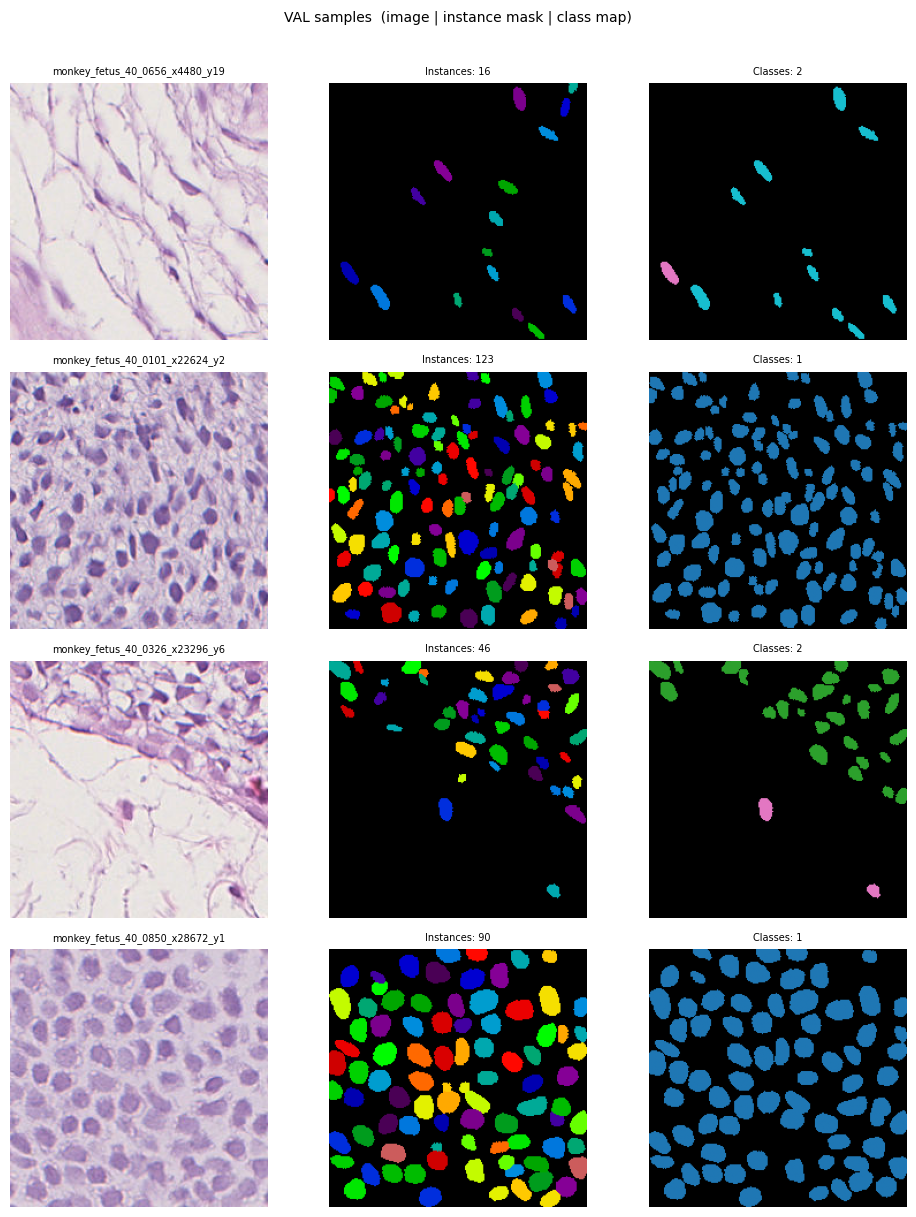

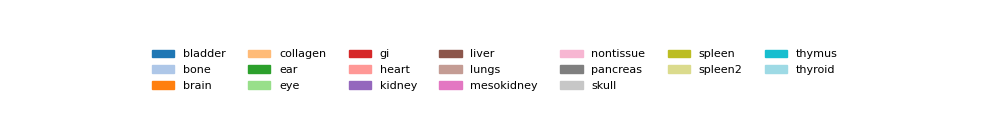

In [10]:
CMAP = plt.cm.get_cmap("tab20", len(CLASS_NAMES))

def visualise_sample(stem: str, ax_row):
    img_path = None
    for ext in (".png", ".jpg", ".tif"):
        cand = TRAIN_IMAGES_DIR / f"{stem}{ext}"
        if cand.exists():
            img_path = cand
            break
    mask_path = find_mask(stem)
    j_path    = INST_LABELS_DIR / f"{stem}_inst2class.json"

    if img_path is None or mask_path is None:
        for ax in ax_row:
            ax.set_visible(False)
        return

    img  = np.asarray(Image.open(img_path).convert("RGB"))
    mask = load_mask_safe(mask_path)
    if mask is None:
        for ax in ax_row:
            ax.set_visible(False)
        return

    # Class map
    class_map = np.full(mask.shape, -1, dtype=np.int32)
    if j_path.exists():
        try:
            inst2cls = json.loads(j_path.read_bytes().decode("utf-8-sig"))
            for inst_id_str, cls_name in inst2cls.items():
                cls_str = str(cls_name).strip().lower()
                try:
                    idx = int(cls_str)
                    if not (0 <= idx < len(CLASS_NAMES)):
                        idx = -1
                except ValueError:
                    idx = CLASS_TO_IDX.get(cls_str, -1)
                class_map[mask == int(inst_id_str)] = idx
        except Exception:
            pass

    ax_row[0].imshow(img)
    ax_row[0].set_title(stem[:30], fontsize=7)
    ax_row[0].axis("off")

    # Colour mask by instance id
    mask_rgb = plt.cm.nipy_spectral((mask % 32) / 32.0)[..., :3]
    mask_rgb[mask == 0] = 0
    ax_row[1].imshow(mask_rgb)
    ax_row[1].set_title(f"Instances: {mask.max()}", fontsize=7)
    ax_row[1].axis("off")

    # Colour class map
    cls_rgb = np.zeros((*mask.shape, 3))
    labeled = 0
    for idx in range(len(CLASS_NAMES)):
        pixels = class_map == idx
        if pixels.any():
            cls_rgb[pixels] = CMAP(idx)[:3]
            labeled += 1
    ax_row[2].imshow(cls_rgb)
    ax_row[2].set_title(f"Classes: {labeled}", fontsize=7)
    ax_row[2].axis("off")

N_VIS = 4
for split_name, stems in [("TRAIN", train_stems), ("VAL", val_stems)]:
    sample = random.sample(stems, min(N_VIS, len(stems)))
    fig, axes = plt.subplots(len(sample), 3, figsize=(10, 3 * len(sample)))
    if len(sample) == 1:
        axes = [axes]
    fig.suptitle(f"{split_name} samples  (image | instance mask | class map)", fontsize=10, y=1.01)
    for row, stem in zip(axes, sample):
        visualise_sample(stem, row)
    plt.tight_layout()
    plt.show()

# Legend
patches = [mpatches.Patch(color=CMAP(i), label=n) for i, n in enumerate(CLASS_NAMES)]
plt.figure(figsize=(10, 1.5))
plt.legend(handles=patches, ncol=7, loc="center", fontsize=8, frameon=False)
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 6b — Export QuPath-compatible GeoJSON for class validation

For every **N-th** tile (configurable), reads the original StarDist JSON polygons + the `inst2class` sidecar, and writes a **QuPath 0.6 GeoJSON** with:
- Nuclear polygons as `PathDetectionObject` features
- `classification.name` = tissue class name (e.g. "liver")
- `classification.color` = `[R, G, B]` matching the `tab20` colour map
- Unclassified nuclei (no entry in `inst2class`) labelled as "unclassified" in grey

Open the tile image in QuPath and drag the `.geojson` on top to visually validate that:
1. Nuclear contours align with H&E staining
2. Class labels make biological sense for the tissue in the tile

In [ ]:
# ── QuPath validation GeoJSON export ──────────────────────────────────────────
import matplotlib.colors as mcolors

QUPATH_VALIDATION_DIR = MT_READY_DIR / "qupath_validation_geojson"
QUPATH_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_EVERY_N = 500   # export 1 tile every N tiles; set to 1 to export all

CMAP_QP = plt.cm.get_cmap("tab20", len(CLASS_NAMES))
CLASS_COLOR_RGB_QP = {
    i: [int(255 * c) for c in CMAP_QP(i)[:3]]
    for i in range(len(CLASS_NAMES))
}
UNCLASSIFIED_COLOR = [180, 180, 180]


def _export_tile_geojson(stem: str, out_dir: Path) -> bool:
    """
    Read StarDist JSON polygons + inst2class sidecar → write one QuPath GeoJSON.
    Returns True if a file was written.
    """
    sd_json_path = STARDIST_JSON_DIR / f"{stem}.json"
    if not sd_json_path.exists():
        return False

    with sd_json_path.open("r", encoding="utf-8") as f:
        polys = json.load(f)
    if not polys:
        return False

    # Load inst2class sidecar (may not exist or may be partial)
    j_path = INST_LABELS_DIR / f"{stem}_inst2class.json"
    inst2cls: dict[str, str] = {}
    if j_path.exists():
        try:
            inst2cls = json.loads(j_path.read_bytes().decode("utf-8-sig"))
            if not isinstance(inst2cls, dict):
                inst2cls = {}
        except Exception:
            inst2cls = {}

    features = []
    for inst_id_0based, obj in enumerate(polys):
        contour = obj.get("contour", [])
        if not contour:
            continue

        inst_id = inst_id_0based + 1   # matches rasterization (enumerate from 1)
        y_coords = contour[0][0]
        x_coords = contour[0][1]

        # GeoJSON polygon ring: [[x,y], ...] closed
        ring = [[float(x), float(y)] for x, y in zip(x_coords, y_coords)]
        if ring and ring[0] != ring[-1]:
            ring.append(ring[0])
        if len(ring) < 4:
            continue

        # Classification from inst2class
        cls_idx_str = inst2cls.get(str(inst_id))
        if cls_idx_str is not None:
            try:
                cls_idx = int(cls_idx_str)
                cls_name = CLASS_NAMES[cls_idx] if 0 <= cls_idx < len(CLASS_NAMES) else "unclassified"
                color = CLASS_COLOR_RGB_QP.get(cls_idx, UNCLASSIFIED_COLOR)
            except (ValueError, IndexError):
                cls_name = "unclassified"
                color = UNCLASSIFIED_COLOR
        else:
            cls_name = "unclassified"
            color = UNCLASSIFIED_COLOR

        features.append({
            "type": "Feature",
            "id": "PathDetectionObject",
            "geometry": {
                "type": "Polygon",
                "coordinates": [ring],
            },
            "properties": {
                "isLocked": False,
                "measurements": [],
                "classification": {
                    "name": cls_name,
                    "color": color,
                },
            },
        })

    if not features:
        return False

    out_path = out_dir / f"{stem}.geojson"
    with out_path.open("w", encoding="utf-8") as f:
        f.write('{"type":"FeatureCollection","features":[\n')
        for i, feat in enumerate(features):
            tail = ",\n" if i + 1 < len(features) else "\n"
            f.write(json.dumps(feat, ensure_ascii=False) + tail)
        f.write("]}\n")
    return True


# ── Export sampled tiles ──────────────────────────────────────────────────────
export_stems = all_stems[::EXPORT_EVERY_N]
print(f"Exporting QuPath validation GeoJSONs for {len(export_stems)} tiles "
      f"(every {EXPORT_EVERY_N} of {len(all_stems)} total)")
print(f"Output dir: {QUPATH_VALIDATION_DIR}")

exported = 0
for stem in tqdm(export_stems, desc="QuPath GeoJSON export"):
    if _export_tile_geojson(stem, QUPATH_VALIDATION_DIR):
        exported += 1

# Also copy the corresponding tile images so you can open them in QuPath
QUPATH_IMAGES_DIR = QUPATH_VALIDATION_DIR / "images"
QUPATH_IMAGES_DIR.mkdir(exist_ok=True)
copied = 0
for stem in export_stems:
    for ext in (".png", ".jpg", ".tif"):
        src = TRAIN_IMAGES_DIR / f"{stem}{ext}"
        if src.exists():
            dst = QUPATH_IMAGES_DIR / f"{stem}{ext}"
            if not dst.exists():
                shutil.copy2(src, dst)
            copied += 1
            break

print(f"\nDone:")
print(f"  GeoJSONs written : {exported}")
print(f"  Tile images copied: {copied}")
print(f"  Open in QuPath: drag a tile image, then drag its .geojson on top.")

# ── Summary of class assignments in exported tiles ────────────────────────────
cls_counts: dict[str, int] = {}
uncls_count = 0
for stem in export_stems:
    gj_path = QUPATH_VALIDATION_DIR / f"{stem}.geojson"
    if not gj_path.exists():
        continue
    try:
        data = json.loads(gj_path.read_text(encoding="utf-8"))
        for feat in data.get("features", []):
            name = feat["properties"]["classification"]["name"]
            if name == "unclassified":
                uncls_count += 1
            else:
                cls_counts[name] = cls_counts.get(name, 0) + 1
    except Exception:
        continue

total = sum(cls_counts.values()) + uncls_count
print(f"\nClass distribution across exported tiles ({total:,} nuclei):")
for name in sorted(cls_counts, key=cls_counts.get, reverse=True):
    print(f"  {name:20s}: {cls_counts[name]:6,}  ({100*cls_counts[name]/max(total,1):.1f}%)")
print(f"  {'unclassified':20s}: {uncls_count:6,}  ({100*uncls_count/max(total,1):.1f}%)")

## Step 7 — Write training config YAML
Generates `config_gs40_multitask.yaml` with the filtered stem lists embedded.  
The explicit stem lists ensure the trainer only uses tiles confirmed valid in Step 4–5.

In [11]:
import yaml
from datetime import datetime
from pathlib import Path as _Path

RUN_TIMESTAMP   = datetime.now().strftime("%Y%m%d_%H%M")
EXPERIMENT_NAME = f"convnext_stardist_mt_gs40_v2_{RUN_TIMESTAMP}"
print(f"Experiment name : {EXPERIMENT_NAME}")

# ── Optional warm-start: set to an existing best.pt to transfer V1 seg weights ─
# Leave as None for a fresh run.
WARMSTART_CHECKPOINT = None
# WARMSTART_CHECKPOINT = _Path(r"\\kittyserverdw\...\best.pt")

cfg = {
    "experiment_name": EXPERIMENT_NAME,
    "data": {
        "train_images_dir": str(TRAIN_IMAGES_DIR),
        "train_labels_dir": str(INST_LABELS_DIR),
        "val_images_dir":   str(TRAIN_IMAGES_DIR),
        "val_labels_dir":   str(INST_LABELS_DIR),
        "train_stems":  train_stems,
        "val_stems":    val_stems,
        "cache_to_ram": False,
    },
    "model": {
        "backbone":          "facebook/convnextv2-tiny-22k-224",
        "pretrained":        True,
        "n_rays":            32,
        "class_names":       CLASS_NAMES,
        "num_classes":       len(CLASS_NAMES),
        "decoder_channels":  128,
        # V2: lightweight semantic skip from encoder stage-4 to cls head
        # Set to 0 to disable (degrades to V1 cls pathway for ablation)
        "cls_semantic_dim":  64,
    },
    "train": {
        "patch_size":             256,
        "batch_size":             4,
        "num_workers":            4,
        "epochs":                 50,
        "lr":                     1e-4,
        "lr_min":                 1e-6,
        "weight_decay":           0.01,
        "amp":                    True,
        "freeze_backbone_epochs": 5,
        "loss_w_prob":            1.0,
        "loss_w_dist":            0.05,
        # V2: classification loss weights (was 0.5 in V1)
        "loss_w_cls":             2.0,
        "loss_w_inst":            0.5,   # instance-level CE weight; 0 to disable
        # V2: class reweighting — "auto" scans inst2class JSONs for inv-sqrt-freq weights
        # Use null for uniform weights; or provide a list of 19 floats.
        "class_weights":          "auto",
        # V2: over-sample tiles that have inst2class supervision (2× vs unlabelled tiles)
        "cls_balanced_sampler":   True,
        # V2: set True to exclude tiles with no inst2class from training entirely
        "cls_only":               False,
    },
    "checkpoint": {
        "out_dir":    str(CKPT_OUT),
        "save_every": 1,
    },
    "infer": {
        "prob_thresh":    0.45,
        "nms_dist":       3,
        "sample_offsets": [0, 128],
    },
}

CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
CONFIG_PATH.write_text(yaml.dump(cfg, default_flow_style=False, sort_keys=False), encoding="utf-8")

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"Config written  : {CONFIG_PATH}")
print(f"  experiment_name      : {cfg['experiment_name']}")
print(f"  train stems          : {len(train_stems)}")
print(f"  val stems            : {len(val_stems)}")
print(f"  num_classes          : {cfg['model']['num_classes']}")
print(f"  class_names          : {CLASS_NAMES}")
print(f"  epochs               : {cfg['train']['epochs']}")
print(f"  batch_size           : {cfg['train']['batch_size']}")
print(f"  lr                   : {cfg['train']['lr']}  -> cosine decay to {cfg['train']['lr_min']}")
print(f"  freeze_backbone      : {cfg['train']['freeze_backbone_epochs']} epochs")
print(f"  cls_semantic_dim     : {cfg['model']['cls_semantic_dim']}  (0 = V1 behaviour)")
print(f"  loss_w_cls / w_inst  : {cfg['train']['loss_w_cls']} / {cfg['train']['loss_w_inst']}")
print(f"  class_weights        : {cfg['train']['class_weights']}")
print(f"  cls_balanced_sampler : {cfg['train']['cls_balanced_sampler']}")
print(f"  checkpoint dir       : {CKPT_OUT}")
if WARMSTART_CHECKPOINT:
    print(f"  warm-start from      : {WARMSTART_CHECKPOINT}")
else:
    print(f"  warm-start           : None (fresh run)")

Experiment name : convnext_stardist_mt_gs40_v2_20260409_1103
Config written  : C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml
  experiment_name      : convnext_stardist_mt_gs40_v2_20260409_1103
  train stems          : 38637
  val stems            : 8006
  num_classes          : 19
  class_names          : ['bladder', 'bone', 'brain', 'collagen', 'ear', 'eye', 'gi', 'heart', 'kidney', 'liver', 'lungs', 'mesokidney', 'nontissue', 'pancreas', 'skull', 'spleen', 'spleen2', 'thymus', 'thyroid']
  epochs               : 50
  batch_size           : 4
  lr                   : 0.0001  -> cosine decay to 1e-06
  freeze_backbone      : 5 epochs
  cls_semantic_dim     : 64  (0 = V1 behaviour)
  loss_w_cls / w_inst  : 2.0 / 0.5
  class_weights        : auto
  cls_balanced_sampler : True
  checkpoint dir       : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_224_40k_48_slides\convnext_stardist_mult

## Step 8 — Run training (V2)

Uses `train_v2.py` with the semantic-skip model, instance-level CE loss, class weights, and balanced sampler.

### From terminal (recommended)
```powershell
conda activate convnext_stardist_mt
cd C:\Users\Andre\cursor_projects\Convnext_stardist

# Fresh run
python -m shared_convnext_stardist_decoder.train_v2 --config shared_convnext_stardist_decoder\config_gs40_multitask.yaml

# Warm-start from V1 best.pt (seg decoder transfers; cls head re-initialises)
python -m shared_convnext_stardist_decoder.train_v2 ^
    --config shared_convnext_stardist_decoder\config_gs40_multitask.yaml ^
    --resume <path_to_v1\best.pt> ^
    --resume_strict false

# Resume a V2 checkpoint (strict load)
python -m shared_convnext_stardist_decoder.train_v2 `
    --config shared_convnext_stardist_decoder\config_gs40_multitask.yaml `
    --resume <path_to_v2\epoch_010.pt>
```

### What to monitor (V2 tqdm shows: `cls_px` and `cls_in` separately)
| Column in log        | Healthy trend |
|----------------------|---------------|
| `train_bce`          | Decreases epoch 1→50 |
| `train_cls_pixel`    | Decreases from ~1.5 toward <0.8 |
| `train_cls_inst`     | Decreases; should track `cls_pixel` |
| `val_cls_pixel`      | Tracks train; large gap = overfitting |
| `train_dist`         | Decreases toward <1.0 |
| `best.pt`            | Saved when `val_loss` improves — use for inference |

> **Warm-start tip:** if starting from a V1 checkpoint, watch `train_cls_inst` in epoch 1.
> It will start high (~3.0) because the new cls head is random, then drop quickly.
> The segmentation metrics (`train_bce`, `train_dist`) should stay stable from epoch 1.

In [12]:
import subprocess, sys
from pathlib import Path

# ── Training script selector ───────────────────────────────────────────────────
# USE_V2 = True  → train_v2 (semantic-skip + instance CE + class weights)
# USE_V2 = False → train    (original V1, for comparison / ablation)
USE_V2 = True

repo_root = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist")
module    = "shared_convnext_stardist_decoder.train_v2" if USE_V2 else "shared_convnext_stardist_decoder.train"

cmd = [sys.executable, "-m", module, "--config", str(CONFIG_PATH)]

# ── Warm-start from a V1 checkpoint (strict=False allows partial load) ─────────
# Set WARMSTART_CHECKPOINT in the config cell above, or override here.
if WARMSTART_CHECKPOINT is not None:
    cmd += ["--resume", str(WARMSTART_CHECKPOINT)]
    if USE_V2:
        cmd += ["--resume_strict", "false"]   # allows V1→V2 partial transfer
    print(f"Warm-starting from : {WARMSTART_CHECKPOINT}")
    print("  → seg decoder weights transfer; cls head (cls_ctx_proj + head_cls) re-initialises")

print("Script       :", module)
print("Config       :", CONFIG_PATH)
print("Working dir  :", repo_root)
print("-" * 70)
result = subprocess.run(cmd, cwd=repo_root)
print("-" * 70)
print(f"Exit code: {result.returncode}")

Script       : shared_convnext_stardist_decoder.train_v2
Config       : C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml
Working dir  : C:\Users\Andre\cursor_projects\Convnext_stardist
----------------------------------------------------------------------


: 

: 